In [32]:
import jax
import sys
original_sys_path = sys.path.copy()
sys.path.append('../utils')
from utils_visualization import *
import scqubits
import numpy as np
from scipy.optimize import minimize


import sys
sys.path.append('../')
from utils_models import *



n_evals = 25
def get_chi(Er,ql1,elements,evals):
    return sum([get_shift_accurate(elements[ql1,ql2], evals[ql2], evals[ql1], Er) for ql2 in range(n_evals)] )

jax_get_chi = jax.jit(jax.vmap(get_chi,in_axes = (0,None,None,None)))


def find_closest_transition(Er,evals):
    arr = np.array([evals[6]-evals[1],
                    evals[8]-evals[1],
                    evals[10]-evals[1],
                    evals[12]-evals[1],
                    evals[14]-evals[1]])
    names = ['06','08','010','012','014']
    differences = jnp.abs(arr - Er)
    closest_index = jnp.argmin(differences)
    return names[closest_index]

def get_transition(EJoverEL, EJoverEC):
    EJ = 4
    EL = EJ/EJoverEL
    EC = EJ/EJoverEC

    qbt = scqubits.Fluxonium(EJ = EJ,EC = EC,EL = EL, cutoff = 110,flux = 0,truncated_dim=n_evals)
    evals = qbt.eigenvals(n_evals)
    elements =  qbt.matrixelement_table(operator = "n_operator",evals_count=n_evals)
    Er_list = np.linspace(evals[3]-evals[1],   evals[11]-evals[1],   int(1e6))

    chi0 = jax_get_chi(Er_list,0,elements,evals)
    chi1 = jax_get_chi(Er_list,1,elements,evals)
    chi2 = jax_get_chi(Er_list,2,elements,evals)

    zero_two_crossovers = np.nonzero(np.diff(np.sign(chi0[:] - chi2[:])))[0]
    results = []
    for crossover in zero_two_crossovers:
        if jnp.all(jnp.abs(chi1[crossover-3:crossover+3] - chi2[crossover-3:crossover+3]) < 1e-3):
            results.append([  Er_list[crossover]/EJ, find_closest_transition(Er_list[crossover],evals), jnp.abs(chi0[crossover] - chi1[crossover]).item()  ])
    

    return max(results, key=lambda t: t[2]) if len(results) != 0 else [None,None,None]

In [35]:


EJoverEC_list =  np.linspace(3.5,5,40)
EJoverEL_list = np.linspace(20,22.5,40)



In [36]:

Er_over_EJ_grid = np.zeros((len(EJoverEL_list), len(EJoverEC_list)))
closest_transition_grid = np.empty((len(EJoverEL_list), len(EJoverEC_list)))
zero_one_diff_grid = np.empty((len(EJoverEL_list), len(EJoverEC_list)))


for i, EJoverEL in enumerate(EJoverEL_list):
    for j, EJoverEC in tqdm(enumerate(EJoverEC_list)):
        Er_over_EJ, closest_transition,zero_one_diff = get_transition(EJoverEL, EJoverEC)
        Er_over_EJ_grid[i, j] = Er_over_EJ
        closest_transition_grid[i, j] = closest_transition
        zero_one_diff_grid[i, j] = zero_one_diff


40it [00:05,  7.97it/s]
40it [00:04,  8.35it/s]
40it [00:02, 14.82it/s]
40it [00:03, 12.77it/s]
40it [00:02, 13.87it/s]
40it [00:02, 15.08it/s]
40it [00:03, 11.82it/s]
40it [00:02, 16.74it/s]
40it [00:02, 16.92it/s]
40it [00:03, 10.89it/s]
40it [00:04,  8.52it/s]
40it [00:04,  8.72it/s]
40it [00:03, 11.29it/s]
40it [00:03, 10.56it/s]
40it [00:03, 10.49it/s]
40it [00:02, 16.16it/s]
40it [00:02, 13.78it/s]
40it [00:03, 10.33it/s]
40it [00:02, 13.62it/s]
40it [00:03, 11.20it/s]
40it [00:04,  8.44it/s]
40it [00:04,  9.09it/s]
40it [00:04,  9.02it/s]
40it [00:03, 12.41it/s]
40it [00:04,  8.86it/s]
40it [00:03, 12.46it/s]
40it [00:02, 13.50it/s]
40it [00:02, 15.54it/s]
40it [00:02, 13.95it/s]
40it [00:06,  6.29it/s]
40it [00:04,  8.99it/s]
40it [00:03, 10.68it/s]
40it [00:03, 10.50it/s]
40it [00:03, 11.61it/s]
40it [00:04,  9.88it/s]
40it [00:04,  9.29it/s]
40it [00:02, 13.68it/s]
40it [00:02, 13.64it/s]
40it [00:04,  9.85it/s]
40it [00:03, 11.47it/s]


In [3]:
# import pickle
# with open('../pickles/sweepECEL.pkl', 'wb') as file:
#     pickle.dump((Er_over_EJ_grid,closest_transition_grid,zero_one_diff_grid), file)


In [3]:
import pickle
with open('../pickles/sweepECEL.pkl', 'rb') as file:
    Er_over_EJ_grid,closest_transition_grid,zero_one_diff_grid = pickle.load( file)


(35.0, 60.0)

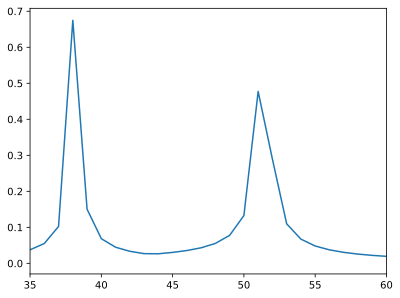

In [11]:
plt.plot(zero_one_diff_grid[:,50])
plt.xlim(35,60)


 /tmp/ipykernel_1644/753078869.py: 2

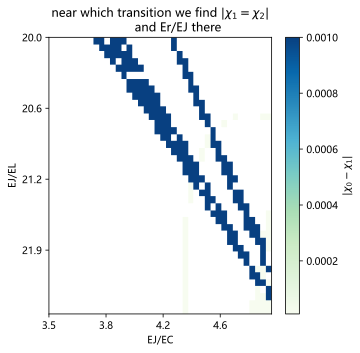

In [37]:
plt.figure(figsize=(5,5))
cmap = plt.cm.get_cmap('GnBu')
im = plt.imshow(zero_one_diff_grid/100, cmap=cmap,vmax = 1e-3,vmin = 1e-5,extent=[EJoverEC_list[0], EJoverEC_list[-1], EJoverEL_list[-1], EJoverEL_list[0]])

# EroverEJ_trunc = np.trunc(Er_over_EJ_grid* 10) / 10
# for i in range(100)[5::10]:
#     for j in range(100)[5::10]:
#         plt.text(EJoverEC_list[i],EJoverEL_list[j],str(int(closest_transition_grid[i,j]))+'\n'+str(EroverEJ_trunc[i,j]),ha='center',va='center')


plt.xticks(ticks = EJoverEC_list[::10],labels = np.trunc(EJoverEC_list[::10] * 10) / 10  )
plt.yticks(ticks = EJoverEL_list[::10],labels =  np.trunc(EJoverEL_list[::10] * 10) / 10 )


cbar = plt.colorbar(im)
cbar.set_label(r'$|\chi_0-\chi_1|$')
plt.xlabel(rf'EJ/EC')
plt.ylabel(rf'EJ/EL')
plt.title(r'''near which transition we find $|\chi_1=\chi_2|$
          and Er/EJ there''')
plt.gca().set_aspect('auto')
plt.savefig('fig01_where_to_find_good_params_fine_grid.pdf', format='pdf', bbox_inches='tight')


(18.0, 21.0)

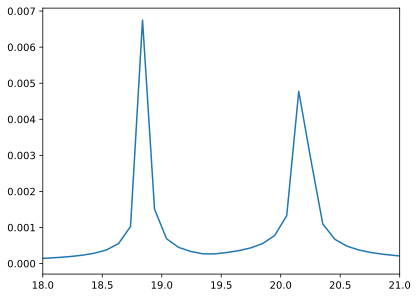

In [13]:
plt.plot(EJoverEL_list, zero_one_diff_grid[:,50]/100)
plt.xlim(18,21)

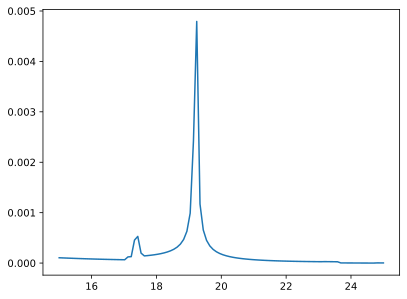

In [38]:
plt.plot(EJoverEL_list, zero_one_diff_grid[:,5]/100)
# plt.xlim(18,21)

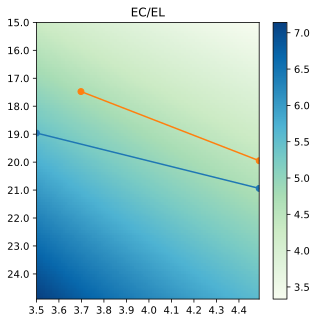

In [39]:
ratio_grid = np.empty((len(EJoverEL_list), len(EJoverEC_list)))


for i, EJoverEL in enumerate(EJoverEL_list):
    for j, EJoverEC in  enumerate(EJoverEC_list):
        ratio_grid[i,j] =EJoverEL/ EJoverEC

plt.figure(figsize=(5,5))
cmap = plt.cm.get_cmap('GnBu')
# im = plt.imshow(ratio_grid, cmap=cmap)
im = plt.imshow(ratio_grid, cmap=cmap,extent=[EJoverEC_list[0], EJoverEC_list[-1], EJoverEL_list[-1], EJoverEL_list[0]])


plt.xticks(ticks = EJoverEC_list[::10],labels = np.trunc(EJoverEC_list[::10] * 10) / 10  )
plt.yticks(ticks = EJoverEL_list[::10],labels =  np.trunc(EJoverEL_list[::10] * 10) / 10 )


plt.plot([3.5,4.5 ], [19, 21], marker='o') 

plt.plot([3.7, 4.5], [17.5, 20], marker='o') 
plt.gca().set_aspect('auto')
plt.title('EC/EL')
plt.colorbar(im)